In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("colorblind")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (8, 5)

In [14]:
# Configuration: Set your timestamp here
TIMESTAMP = "20260104_162939"  # Change this to your profiling run timestamp
BASE_PATH = Path(f"results/nsys/{TIMESTAMP}")

# Define implementations to analyze
CUDA_IMPLS = ["optimized-cuda", "sparse-cuda"]
MPI_IMPLS = [
    "naive-cuda-mpi-linear",
    "naive-cuda-mpi-louvain", 
    "naive-cuda-mpi-red-blue",
    "optimized-cuda-mpi-linear",
    "optimized-cuda-mpi-louvain",
    "optimized-cuda-mpi-red-blue"
]
ALL_IMPLS = CUDA_IMPLS + MPI_IMPLS

# Output directory for figures
OUTPUT_DIR = Path(f"results/nsys/{TIMESTAMP}/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Analysis base path: {BASE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nChecking available implementations...")
for impl in ALL_IMPLS:
    impl_path = BASE_PATH / impl
    status = "✓" if impl_path.exists() else "✗"
    print(f"{status} {impl}")

Analysis base path: results/nsys/20260104_162939
Output directory: results/nsys/20260104_162939/figures

Checking available implementations...
✓ optimized-cuda
✓ sparse-cuda
✓ naive-cuda-mpi-linear
✓ naive-cuda-mpi-louvain
✓ naive-cuda-mpi-red-blue
✓ optimized-cuda-mpi-linear
✓ optimized-cuda-mpi-louvain
✓ optimized-cuda-mpi-red-blue


## Data Loading Functions

In [15]:
from glob import glob
def load_csv_safely(impl, file_suffix):
    """Load a CSV file for a given implementation, return None if not found."""
    matched_files = glob(str(BASE_PATH / impl / f"*{file_suffix}"))
    if not matched_files:
        return None
    filepath = Path(matched_files[0])
    if filepath.exists():
        try:
            return pd.read_csv(filepath)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
    return None

def load_all_implementations(filename):
    """Load a specific CSV file for all implementations."""
    data = {}
    for impl in ALL_IMPLS:
        df = load_csv_safely(impl, filename)
        if df is not None:
            data[impl] = df
    return data

def get_total_time_ns(impl):
    """Get total execution time for an implementation."""
    # Try to get from CUDA API sum first
    df = load_csv_safely(impl, "stats_cuda_api_sum.csv")
    if df is not None and 'Total Time (ns)' in df.columns:
        return df['Total Time (ns)'].sum()
    return None

print("Data loading functions defined.")

Data loading functions defined.


## Visualization 1: Time Distribution - CPU vs CUDA vs MPI

**Purpose**: Shows the fundamental architecture benefit of GPU acceleration and identifies MPI communication overhead in distributed implementations.

Error loading results/nsys/20260104_162939/optimized-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/sparse-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file


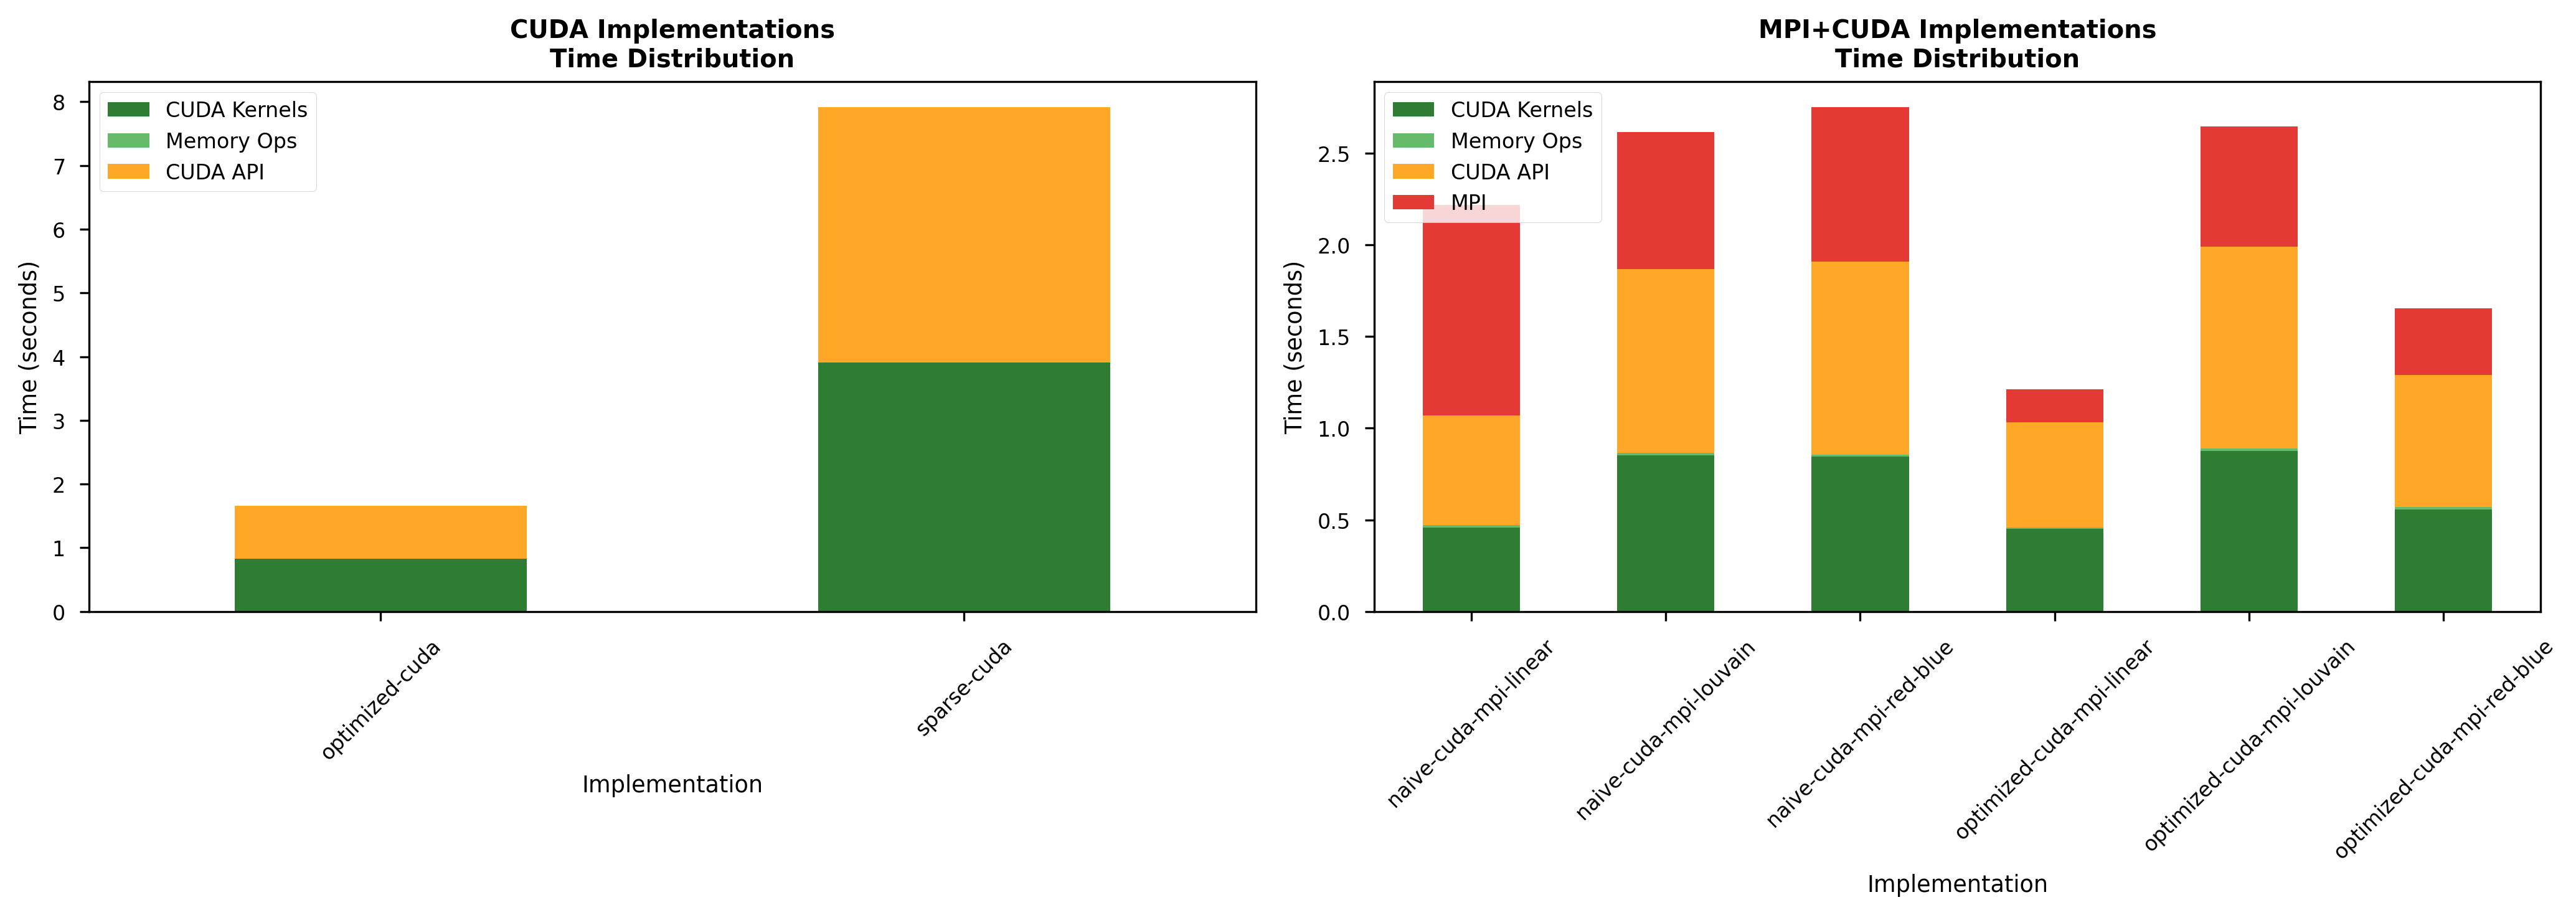


Time Distribution Summary (seconds):
             implementation  cuda_kernel  cuda_memory  cuda_api      mpi
             optimized-cuda     0.825918     0.000004  0.829800 0.000000
                sparse-cuda     3.909965     0.000003  4.007511 0.000000
      naive-cuda-mpi-linear     0.457780     0.012074  0.598609 1.149331
     naive-cuda-mpi-louvain     0.853007     0.012562  1.002563 0.745665
    naive-cuda-mpi-red-blue     0.843909     0.011028  1.052883 0.844331
  optimized-cuda-mpi-linear     0.449580     0.008926  0.574928 0.179156
 optimized-cuda-mpi-louvain     0.875522     0.015295  1.097668 0.658153
optimized-cuda-mpi-red-blue     0.557270     0.013106  0.719118 0.363725


In [16]:
def calculate_time_breakdown(impl):
    """Calculate time spent in CUDA kernels, CUDA API, and MPI."""
    result = {'implementation': impl}
    
    # Load CUDA GPU data (kernels + memory)
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv")
    if gpu_df is not None:
        cuda_kernel_time = gpu_df[gpu_df['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
        cuda_mem_time = gpu_df[gpu_df['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        cuda_api_time = gpu_df[gpu_df['Category'] == 'CUDA_API']['Total Time (ns)'].sum()
        
        result['cuda_kernel'] = cuda_kernel_time / 1e9  # Convert to seconds
        result['cuda_memory'] = cuda_mem_time / 1e9
        result['cuda_api'] = cuda_api_time / 1e9
    
    # Load MPI data if available
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv")
    if mpi_df is not None:
        result['mpi'] = mpi_df['Total Time (ns)'].sum() / 1e9
    else:
        result['mpi'] = 0
    
    return result

# Calculate for all implementations
time_breakdown = [calculate_time_breakdown(impl) for impl in ALL_IMPLS]
time_df = pd.DataFrame(time_breakdown)

# Create figure with subplots for CUDA and MPI implementations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CUDA-only implementations
cuda_data = time_df[time_df['implementation'].isin(CUDA_IMPLS)]
if not cuda_data.empty:
    ax = axes[0]
    cuda_plot_data = cuda_data.set_index('implementation')[['cuda_kernel', 'cuda_memory', 'cuda_api']]
    cuda_plot_data.plot(kind='bar', stacked=True, ax=ax, 
                        color=['#2E7D32', '#66BB6A', '#FFA726'])
    ax.set_title('CUDA Implementations\nTime Distribution', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (seconds)')
    ax.legend(['CUDA Kernels', 'Memory Ops', 'CUDA API'], loc='upper left')
    ax.tick_params(axis='x', rotation=45)

# Plot 2: MPI+CUDA implementations
mpi_data = time_df[time_df['implementation'].isin(MPI_IMPLS)]
if not mpi_data.empty:
    ax = axes[1]
    mpi_plot_data = mpi_data.set_index('implementation')[['cuda_kernel', 'cuda_memory', 'cuda_api', 'mpi']]
    mpi_plot_data.plot(kind='bar', stacked=True, ax=ax,
                       color=['#2E7D32', '#66BB6A', '#FFA726', '#E53935'])
    ax.set_title('MPI+CUDA Implementations\nTime Distribution', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (seconds)')
    ax.legend(['CUDA Kernels', 'Memory Ops', 'CUDA API', 'MPI'], loc='upper left')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'time_distribution.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'time_distribution.png', bbox_inches='tight')
plt.show()

print("\nTime Distribution Summary (seconds):")
print(time_df.to_string(index=False))

## Visualization 2: Kernel Performance Breakdown

**Purpose**: Identifies which kernels dominate execution time and shows optimization effectiveness.

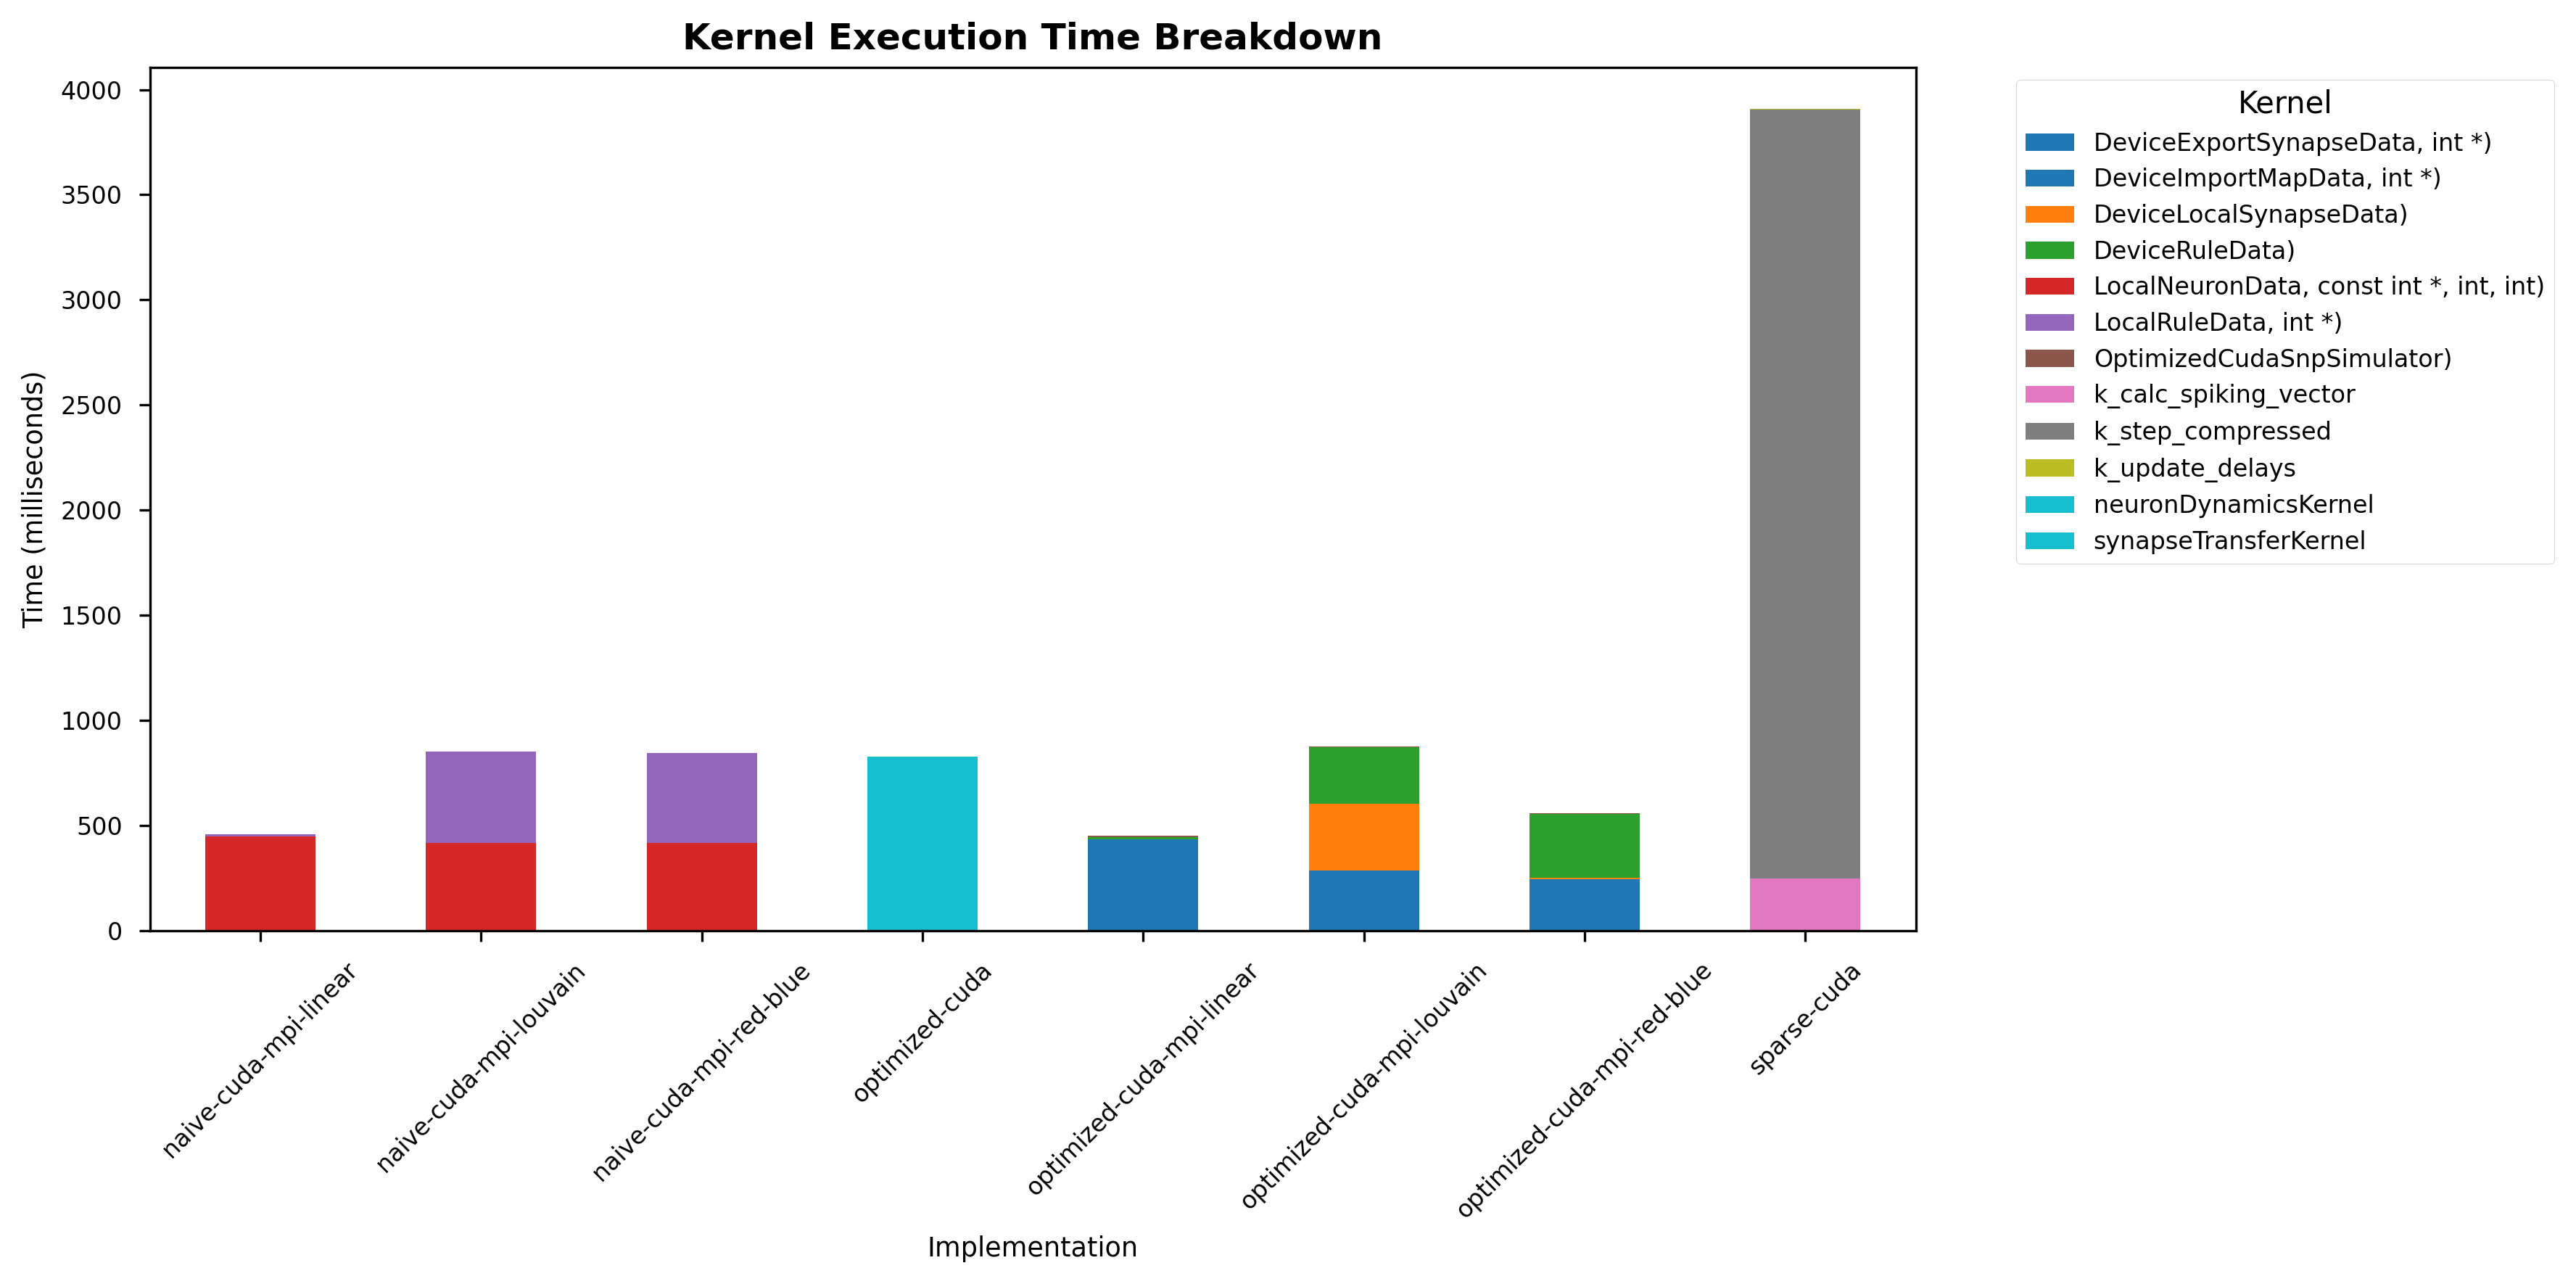


Top 3 kernels by time for each implementation:

optimized-cuda:
  neuronDynamicsKernel: 427.45 ms (51.8%)
  synapseTransferKernel: 398.47 ms (48.2%)

sparse-cuda:
  k_step_compressed: 3658.34 ms (93.6%)
  k_calc_spiking_vector: 248.08 ms (6.3%)
  k_update_delays: 3.54 ms (0.1%)

naive-cuda-mpi-linear:
  LocalNeuronData, const int *, int, int): 446.58 ms (97.6%)
  LocalRuleData, int *): 11.20 ms (2.4%)

naive-cuda-mpi-louvain:
  LocalRuleData, int *): 435.11 ms (51.0%)
  LocalNeuronData, const int *, int, int): 417.89 ms (49.0%)

naive-cuda-mpi-red-blue:
  LocalRuleData, int *): 427.24 ms (50.6%)
  LocalNeuronData, const int *, int, int): 416.67 ms (49.4%)

optimized-cuda-mpi-linear:
  DeviceExportSynapseData, int *): 434.91 ms (96.7%)
  DeviceRuleData): 9.91 ms (2.2%)
  OptimizedCudaSnpSimulator): 4.75 ms (1.1%)

optimized-cuda-mpi-louvain:
  DeviceLocalSynapseData): 318.00 ms (36.3%)
  DeviceExportSynapseData, int *): 279.54 ms (31.9%)
  DeviceRuleData): 268.40 ms (30.7%)

optimized-

In [17]:
# Load kernel data for all implementations
kernel_data = load_all_implementations("stats_cuda_gpu_kern_sum.csv")

# Process and prepare data
kernel_times = []
for impl, df in kernel_data.items():
    if df is not None and not df.empty:
        for _, row in df.iterrows():
            kernel_name = row['Name'].split('::')[-1].replace('(<unnamed>', '').split('(')[0]
            kernel_times.append({
                'implementation': impl,
                'kernel': kernel_name,
                'time_ms': row['Total Time (ns)'] / 1e6,
                'percentage': row['Time (%)']
            })

kernel_df = pd.DataFrame(kernel_times)

if not kernel_df.empty:
    # Create pivot table for stacked bar chart
    pivot_data = kernel_df.pivot_table(index='implementation', columns='kernel', 
                                       values='time_ms', fill_value=0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title('Kernel Execution Time Breakdown', fontweight='bold', fontsize=12)
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (milliseconds)')
    ax.legend(title='Kernel', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'kernel_breakdown.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'kernel_breakdown.png', bbox_inches='tight')
    plt.show()
    
    print("\nTop 3 kernels by time for each implementation:")
    for impl in kernel_df['implementation'].unique():
        impl_data = kernel_df[kernel_df['implementation'] == impl].nlargest(3, 'time_ms')
        print(f"\n{impl}:")
        for _, row in impl_data.iterrows():
            print(f"  {row['kernel']}: {row['time_ms']:.2f} ms ({row['percentage']:.1f}%)")
else:
    print("No kernel data available.")

## Visualization 3: MPI Communication Analysis

**Purpose**: Quantifies MPI overhead and shows the impact of different communication patterns.

Error loading results/nsys/20260104_162939/optimized-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/sparse-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file


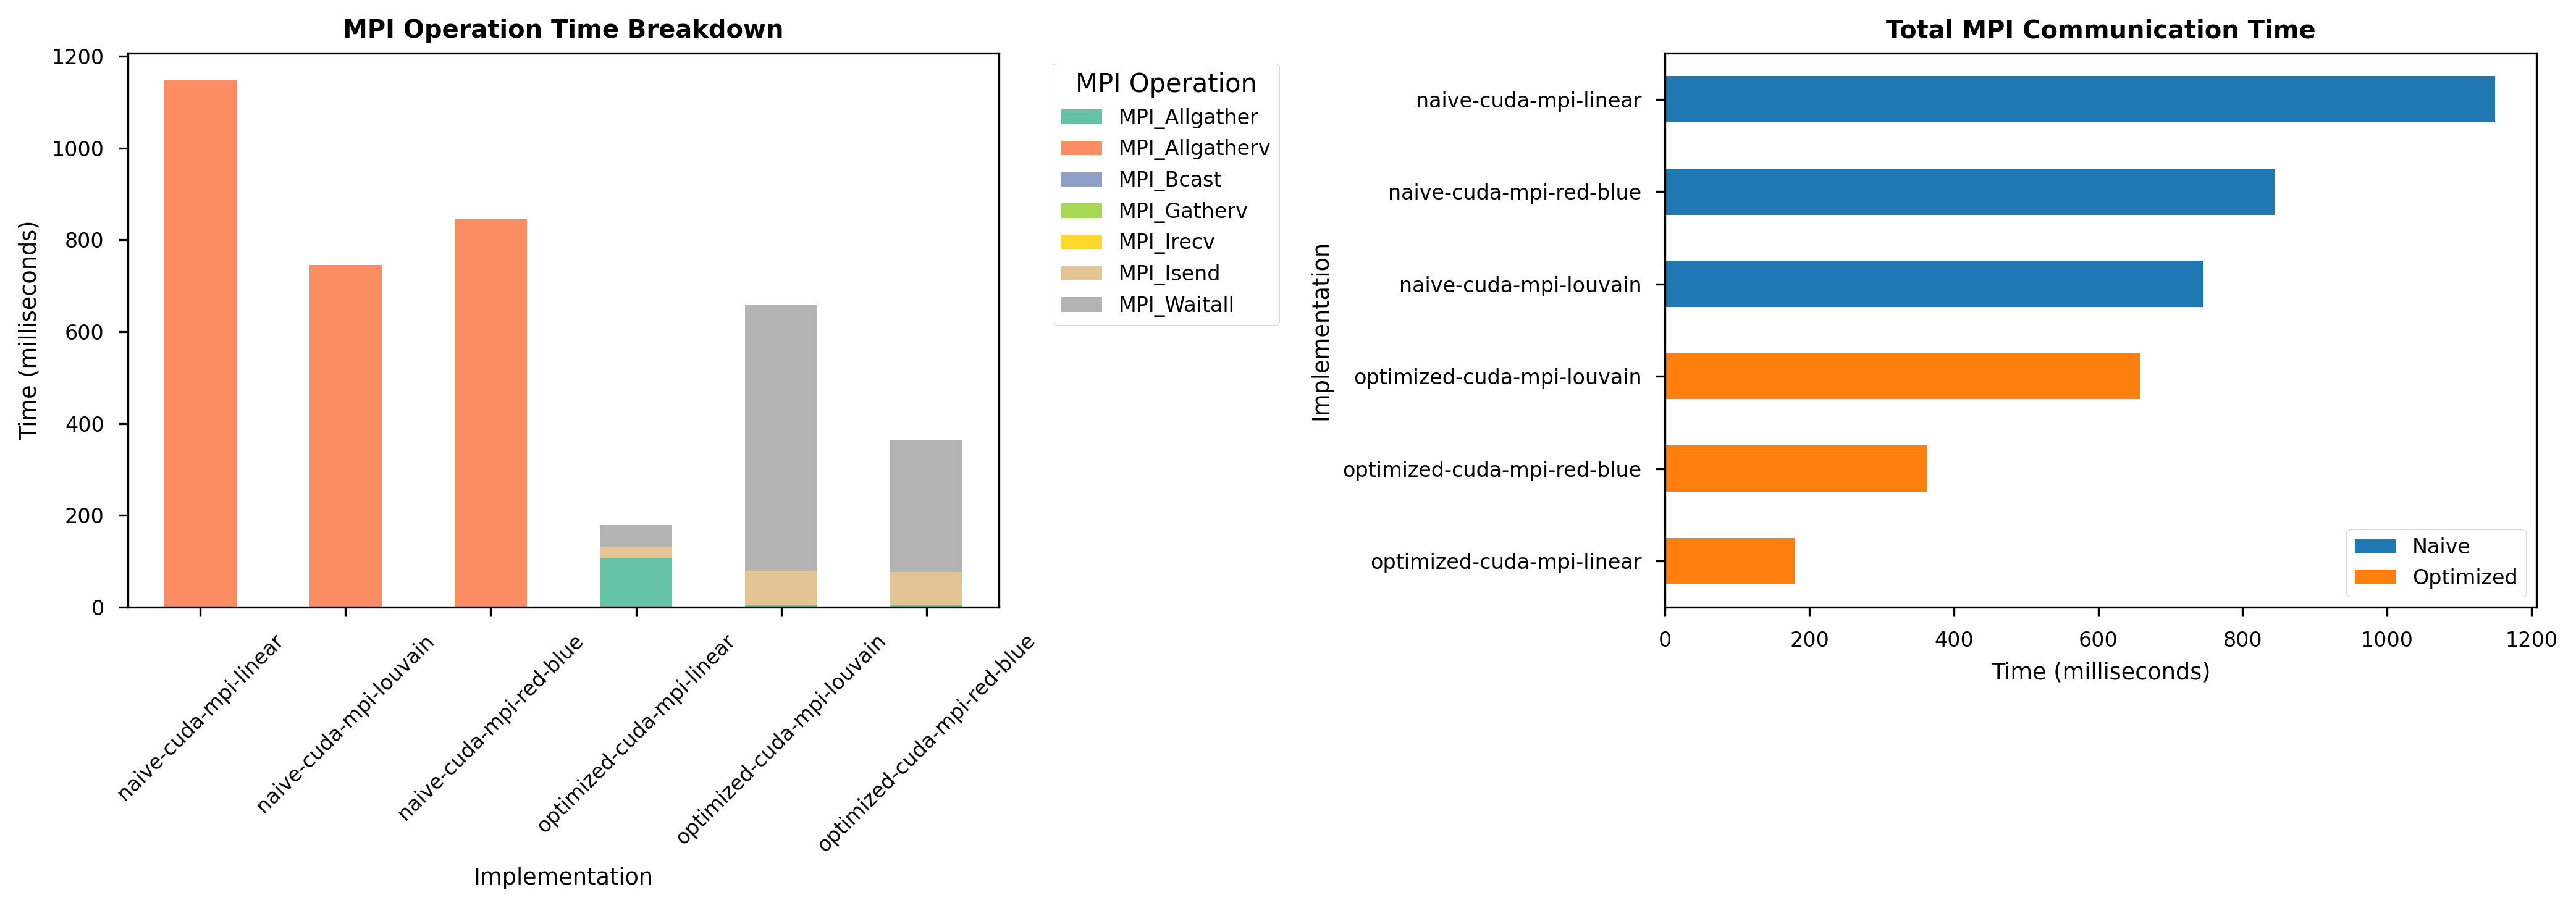


MPI Communication Summary:
implementation
optimized-cuda-mpi-linear       179.156033
optimized-cuda-mpi-red-blue     363.725256
optimized-cuda-mpi-louvain      658.152574
naive-cuda-mpi-louvain          745.664725
naive-cuda-mpi-red-blue         844.331057
naive-cuda-mpi-linear          1149.331054


In [18]:
# Load MPI event data
mpi_data = load_all_implementations("stats_mpi_event_sum.csv")

# Process MPI operations
mpi_operations = []
for impl, df in mpi_data.items():
    if df is not None and not df.empty:
        for _, row in df.iterrows():
            mpi_operations.append({
                'implementation': impl,
                'operation': row['Name'],
                'time_ms': row['Total Time (ns)'] / 1e6,
                'percentage': row['Time (%)']
            })

mpi_op_df = pd.DataFrame(mpi_operations)

if not mpi_op_df.empty:
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Stacked bar chart of MPI operations
    ax = axes[0]
    pivot_mpi = mpi_op_df.pivot_table(index='implementation', columns='operation',
                                      values='time_ms', fill_value=0)
    pivot_mpi.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title('MPI Operation Time Breakdown', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (milliseconds)')
    ax.legend(title='MPI Operation', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    
    # Plot 2: Total MPI time comparison
    ax = axes[1]
    total_mpi_time = mpi_op_df.groupby('implementation')['time_ms'].sum().sort_values()
    colors = ['#1f77b4' if 'naive' in impl else '#ff7f0e' for impl in total_mpi_time.index]
    total_mpi_time.plot(kind='barh', ax=ax, color=colors)
    ax.set_title('Total MPI Communication Time', fontweight='bold')
    ax.set_xlabel('Time (milliseconds)')
    ax.set_ylabel('Implementation')
    
    # Add legend for naive vs optimized
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1f77b4', label='Naive'),
                      Patch(facecolor='#ff7f0e', label='Optimized')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'mpi_communication.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'mpi_communication.png', bbox_inches='tight')
    plt.show()
    
    print("\nMPI Communication Summary:")
    print(total_mpi_time.to_string())
else:
    print("No MPI data available.")

## Visualization 4: MPI Message Volume Analysis

**Purpose**: Shows data movement patterns and their relationship to communication time.

Error loading results/nsys/20260104_162939/optimized-cuda/snp_profile_stats_mpi_msg_size_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/sparse-cuda/snp_profile_stats_mpi_msg_size_sum.csv: No columns to parse from file


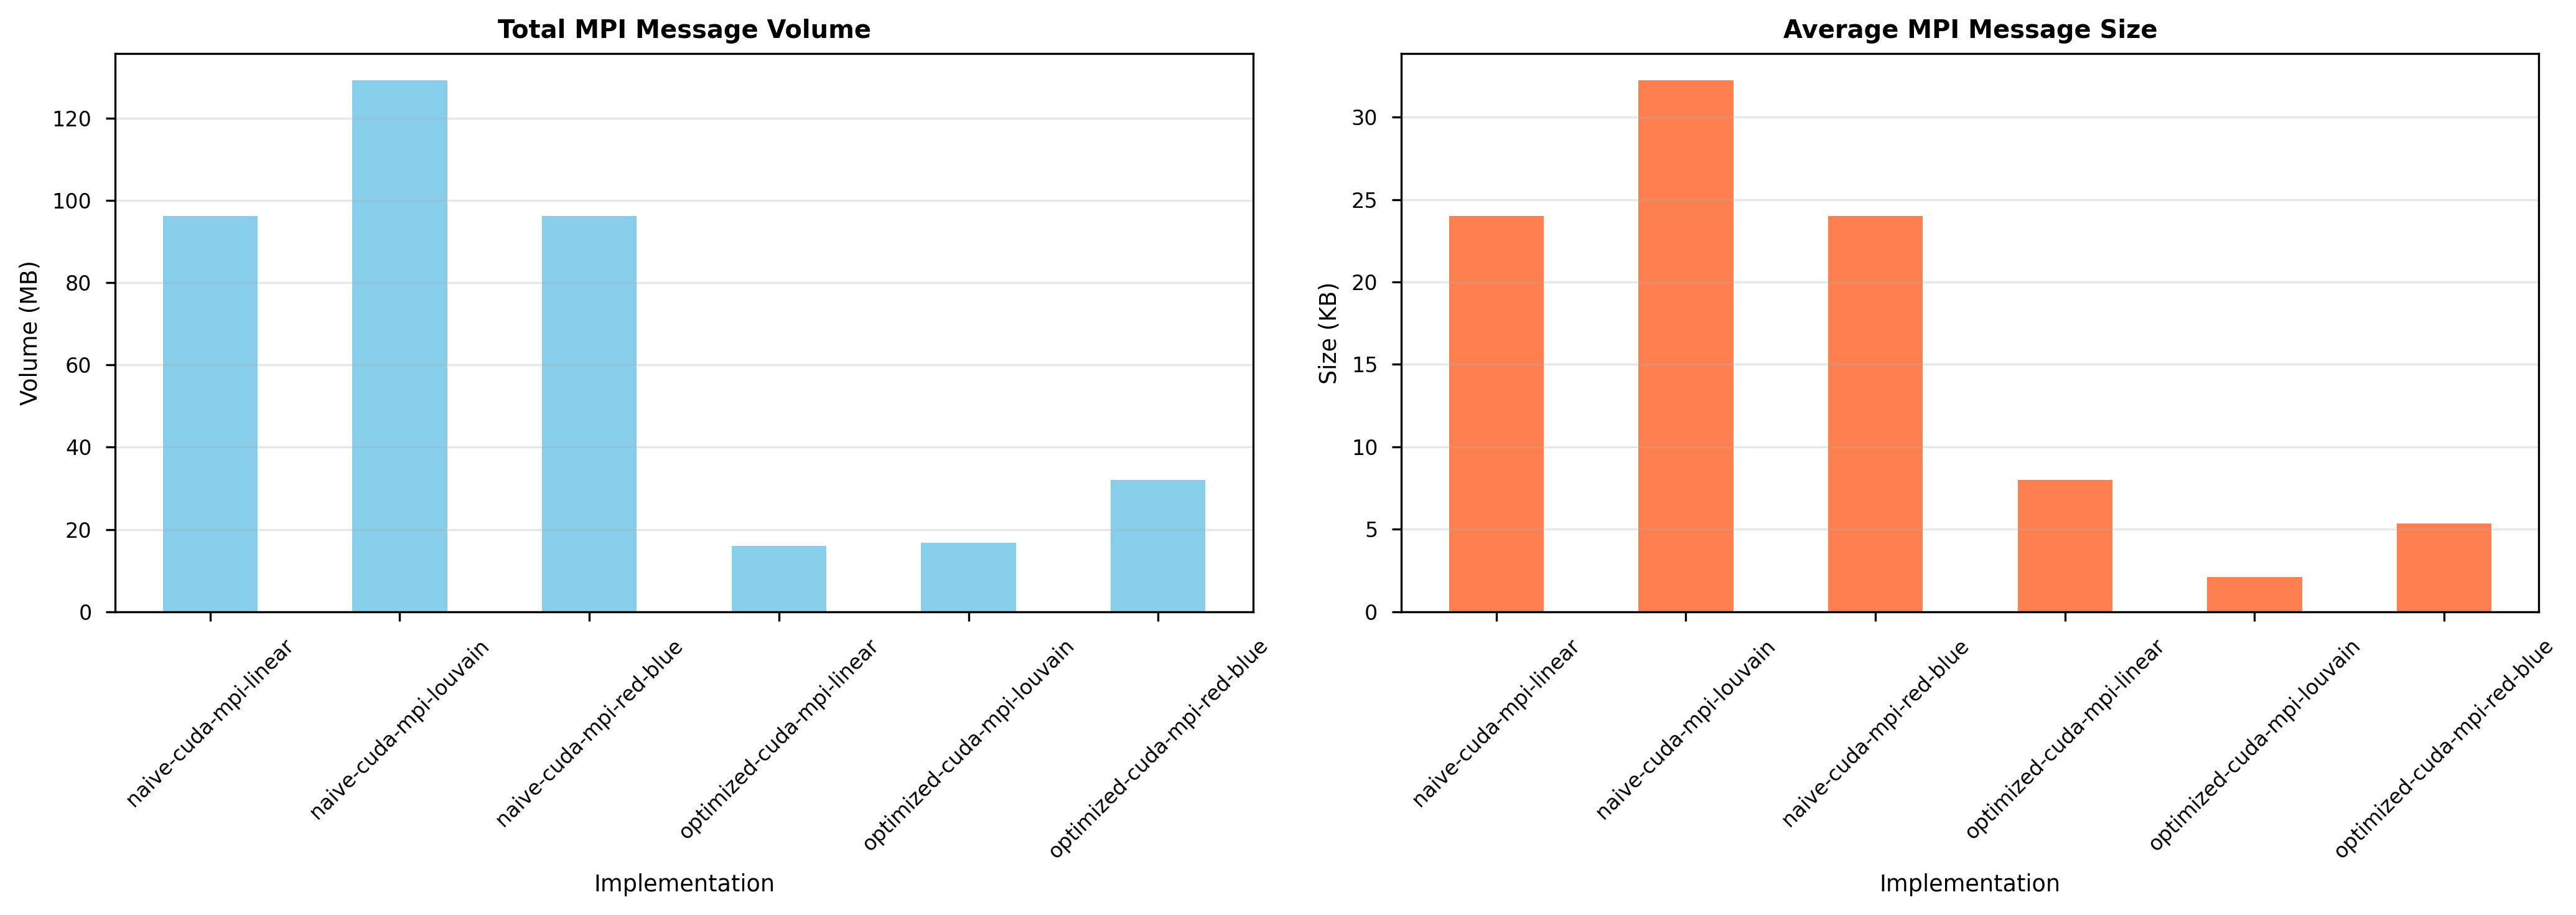


MPI Message Volume Summary:
             implementation  volume_mb  instances  avg_msg_size_kb
      naive-cuda-mpi-linear  96.218750       4104        24.007797
     naive-cuda-mpi-louvain 129.232883       4104        32.245242
    naive-cuda-mpi-red-blue  96.218750       4104        24.007797
  optimized-cuda-mpi-linear  16.062523       2054         8.007801
 optimized-cuda-mpi-louvain  16.727695       8204         2.087903
optimized-cuda-mpi-red-blue  32.078148       6154         5.337670


In [19]:
# Load MPI message size data
mpi_msg_data = load_all_implementations("stats_mpi_msg_size_sum.csv")

# Process message volumes
msg_volumes = []
for impl, df in mpi_msg_data.items():
    if df is not None and not df.empty:
        total_volume = df['Total Message Volume'].sum()
        msg_volumes.append({
            'implementation': impl,
            'volume_mb': total_volume / (1024 * 1024),
            'instances': df['Instances'].sum()
        })

msg_vol_df = pd.DataFrame(msg_volumes)

if not msg_vol_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Message volume by implementation
    ax = axes[0]
    msg_vol_df.set_index('implementation')['volume_mb'].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('Total MPI Message Volume', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Volume (MB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: Average message size
    ax = axes[1]
    msg_vol_df['avg_msg_size_kb'] = (msg_vol_df['volume_mb'] * 1024) / msg_vol_df['instances']
    msg_vol_df.set_index('implementation')['avg_msg_size_kb'].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Average MPI Message Size', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Size (KB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'mpi_message_volume.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'mpi_message_volume.png', bbox_inches='tight')
    plt.show()
    
    print("\nMPI Message Volume Summary:")
    print(msg_vol_df.to_string(index=False))
else:
    print("No MPI message data available.")

## Visualization 5: Partitioning Strategy Comparison

**Purpose**: Key contribution - compares linear, Louvain, and Red-Blue partitioning strategies.

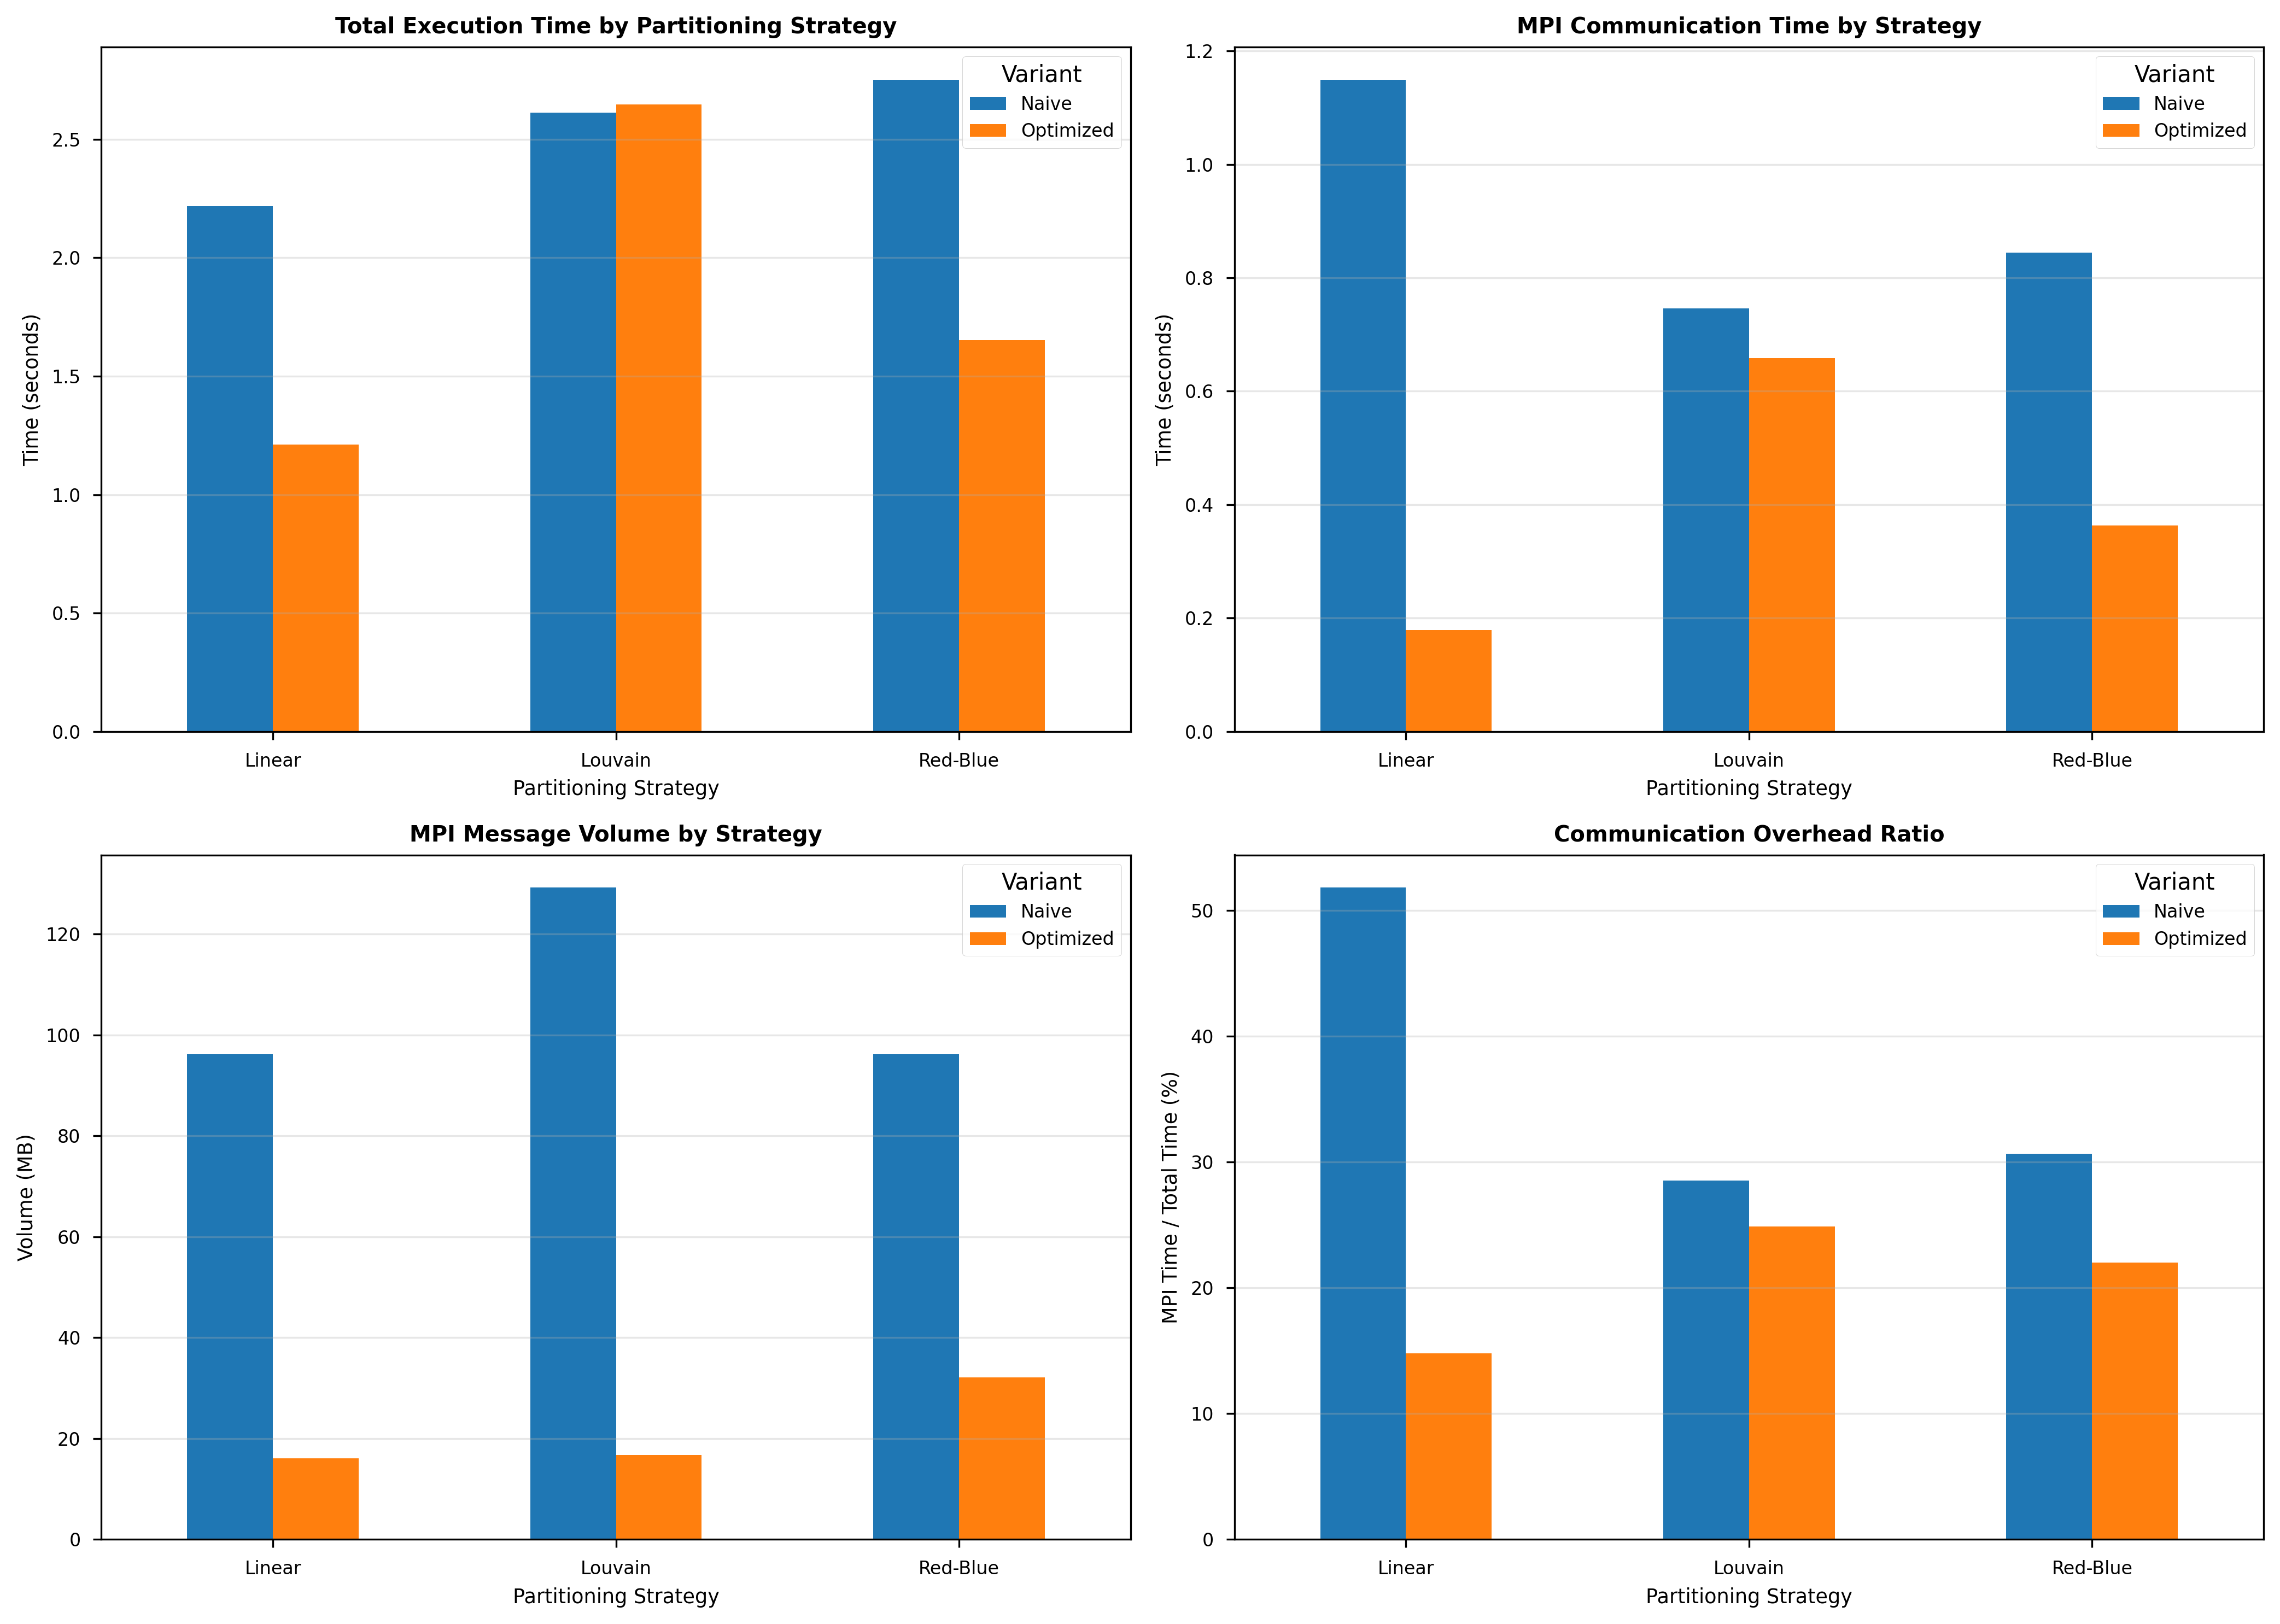


Partitioning Strategy Comparison:
strategy   variant  mpi_time_s  cuda_time_s  total_time_s  msg_volume_mb  comm_ratio
  Linear     Naive    1.149331     1.068462      2.217793      96.218750   51.823187
 Louvain     Naive    0.745665     1.868132      2.613797     129.232883   28.528032
Red-Blue     Naive    0.844331     1.907820      2.752151      96.218750   30.678947
  Linear Optimized    0.179156     1.033434      1.212590      16.062523   14.774655
 Louvain Optimized    0.658153     1.988485      2.646637      16.727695   24.867502
Red-Blue Optimized    0.363725     1.289495      1.653220      32.078148   22.001020


In [20]:
# Compare partitioning strategies
def extract_strategy(impl_name):
    """Extract partitioning strategy from implementation name."""
    if 'linear' in impl_name:
        return 'Linear'
    elif 'louvain' in impl_name:
        return 'Louvain'
    elif 'red-blue' in impl_name:
        return 'Red-Blue'
    return None

def extract_variant(impl_name):
    """Extract naive vs optimized variant."""
    return 'Naive' if 'naive' in impl_name else 'Optimized'

# Prepare comparison data
comparison_data = []
for impl in MPI_IMPLS:
    strategy = extract_strategy(impl)
    variant = extract_variant(impl)
    
    # Get MPI time
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv")
    mpi_time = mpi_df['Total Time (ns)'].sum() / 1e9 if mpi_df is not None else 0
    
    # Get total CUDA time
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv")
    cuda_time = gpu_df['Total Time (ns)'].sum() / 1e9 if gpu_df is not None else 0
    
    # Get message volume
    msg_df = load_csv_safely(impl, "stats_mpi_msg_size_sum.csv")
    msg_volume = msg_df['Total Message Volume'].sum() / (1024*1024) if msg_df is not None else 0
    
    comparison_data.append({
        'strategy': strategy,
        'variant': variant,
        'mpi_time_s': mpi_time,
        'cuda_time_s': cuda_time,
        'total_time_s': mpi_time + cuda_time,
        'msg_volume_mb': msg_volume,
        'comm_ratio': mpi_time / (mpi_time + cuda_time) * 100 if (mpi_time + cuda_time) > 0 else 0
    })

comp_df = pd.DataFrame(comparison_data)

if not comp_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Total execution time by strategy
    ax = axes[0, 0]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='total_time_s')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('Total Execution Time by Partitioning Strategy', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('Time (seconds)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: MPI communication time
    ax = axes[0, 1]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='mpi_time_s')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('MPI Communication Time by Strategy', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('Time (seconds)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: Message volume
    ax = axes[1, 0]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='msg_volume_mb')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('MPI Message Volume by Strategy', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('Volume (MB)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 4: Communication ratio (MPI time / total time)
    ax = axes[1, 1]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='comm_ratio')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('Communication Overhead Ratio', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('MPI Time / Total Time (%)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'partitioning_comparison.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'partitioning_comparison.png', bbox_inches='tight')
    plt.show()
    
    print("\nPartitioning Strategy Comparison:")
    print(comp_df.to_string(index=False))
else:
    print("No comparison data available.")

## Visualization 6: Overall Performance Comparison

**Purpose**: Speedup analysis showing relative performance of all implementations.

Error loading results/nsys/20260104_162939/optimized-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/sparse-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file


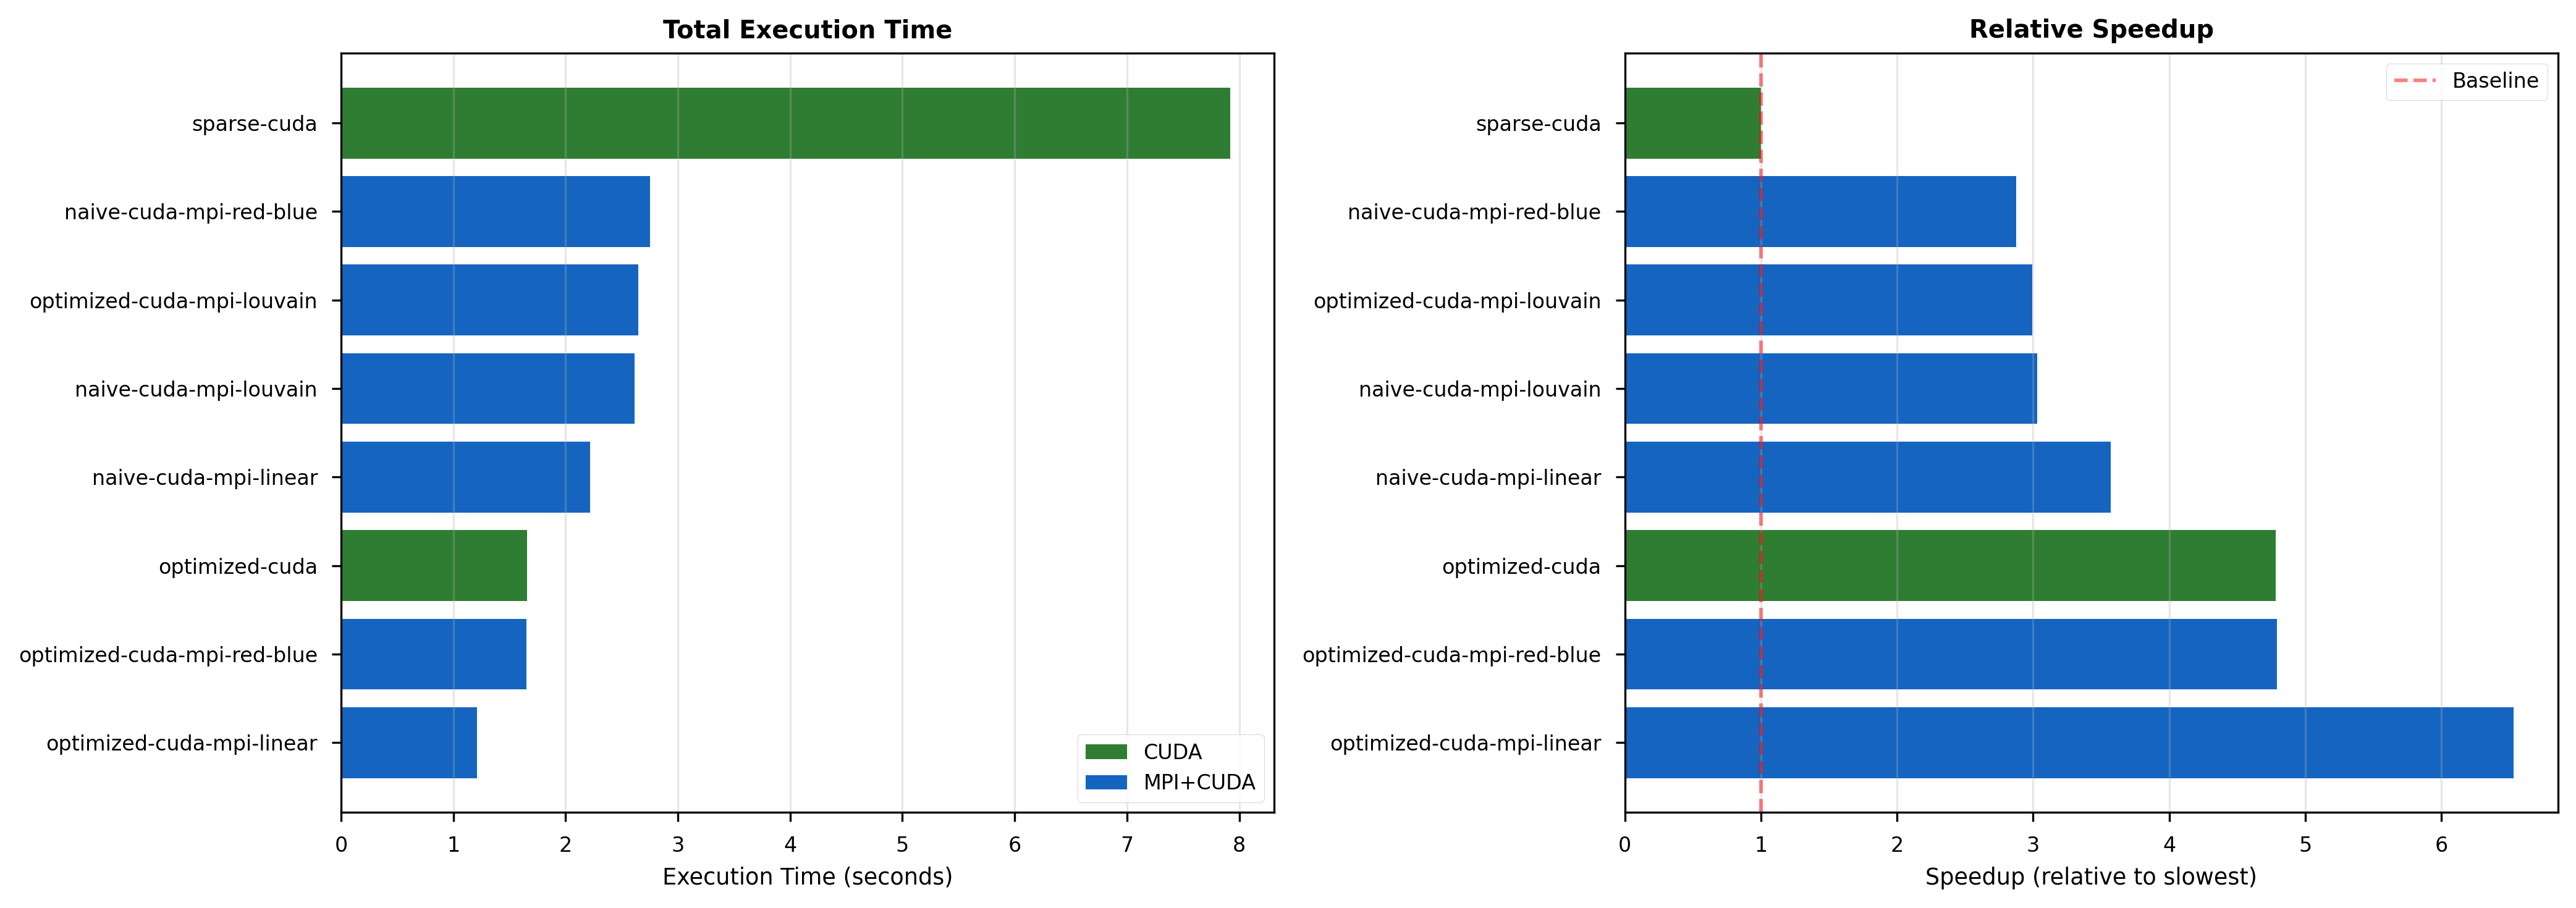


Overall Performance Summary:
             implementation  total_time_s  speedup
  optimized-cuda-mpi-linear      1.212590 6.529393
optimized-cuda-mpi-red-blue      1.653220 4.789126
             optimized-cuda      1.655722 4.781890
      naive-cuda-mpi-linear      2.217793 3.569981
     naive-cuda-mpi-louvain      2.613797 3.029111
 optimized-cuda-mpi-louvain      2.646637 2.991524
    naive-cuda-mpi-red-blue      2.752151 2.876833
                sparse-cuda      7.917479 1.000000


In [21]:
# Calculate total execution time for all implementations
perf_data = []
for impl in ALL_IMPLS:
    # Sum all major components
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv")
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv")
    
    cuda_time = gpu_df['Total Time (ns)'].sum() / 1e9 if gpu_df is not None else 0
    mpi_time = mpi_df['Total Time (ns)'].sum() / 1e9 if mpi_df is not None else 0
    total_time = cuda_time + mpi_time
    
    perf_data.append({
        'implementation': impl,
        'total_time_s': total_time,
        'type': 'CUDA' if impl in CUDA_IMPLS else 'MPI+CUDA'
    })

perf_df = pd.DataFrame(perf_data)
perf_df = perf_df.sort_values('total_time_s')

if not perf_df.empty and perf_df['total_time_s'].max() > 0:
    # Calculate speedup relative to slowest implementation
    baseline = perf_df['total_time_s'].max()
    perf_df['speedup'] = baseline / perf_df['total_time_s']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Absolute execution time
    ax = axes[0]
    colors = ['#2E7D32' if t == 'CUDA' else '#1565C0' for t in perf_df['type']]
    bars = ax.barh(range(len(perf_df)), perf_df['total_time_s'], color=colors)
    ax.set_yticks(range(len(perf_df)))
    ax.set_yticklabels(perf_df['implementation'])
    ax.set_xlabel('Execution Time (seconds)')
    ax.set_title('Total Execution Time', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2E7D32', label='CUDA'),
                      Patch(facecolor='#1565C0', label='MPI+CUDA')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # Plot 2: Speedup
    ax = axes[1]
    bars = ax.barh(range(len(perf_df)), perf_df['speedup'], color=colors)
    ax.set_yticks(range(len(perf_df)))
    ax.set_yticklabels(perf_df['implementation'])
    ax.set_xlabel('Speedup (relative to slowest)')
    ax.set_title('Relative Speedup', fontweight='bold')
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Baseline')
    ax.grid(axis='x', alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'overall_performance.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'overall_performance.png', bbox_inches='tight')
    plt.show()
    
    print("\nOverall Performance Summary:")
    print(perf_df[['implementation', 'total_time_s', 'speedup']].to_string(index=False))
else:
    print("Insufficient performance data available.")

## Visualization 7: CUDA API Overhead Analysis

**Purpose**: Shows synchronization and launch overhead impact on performance.

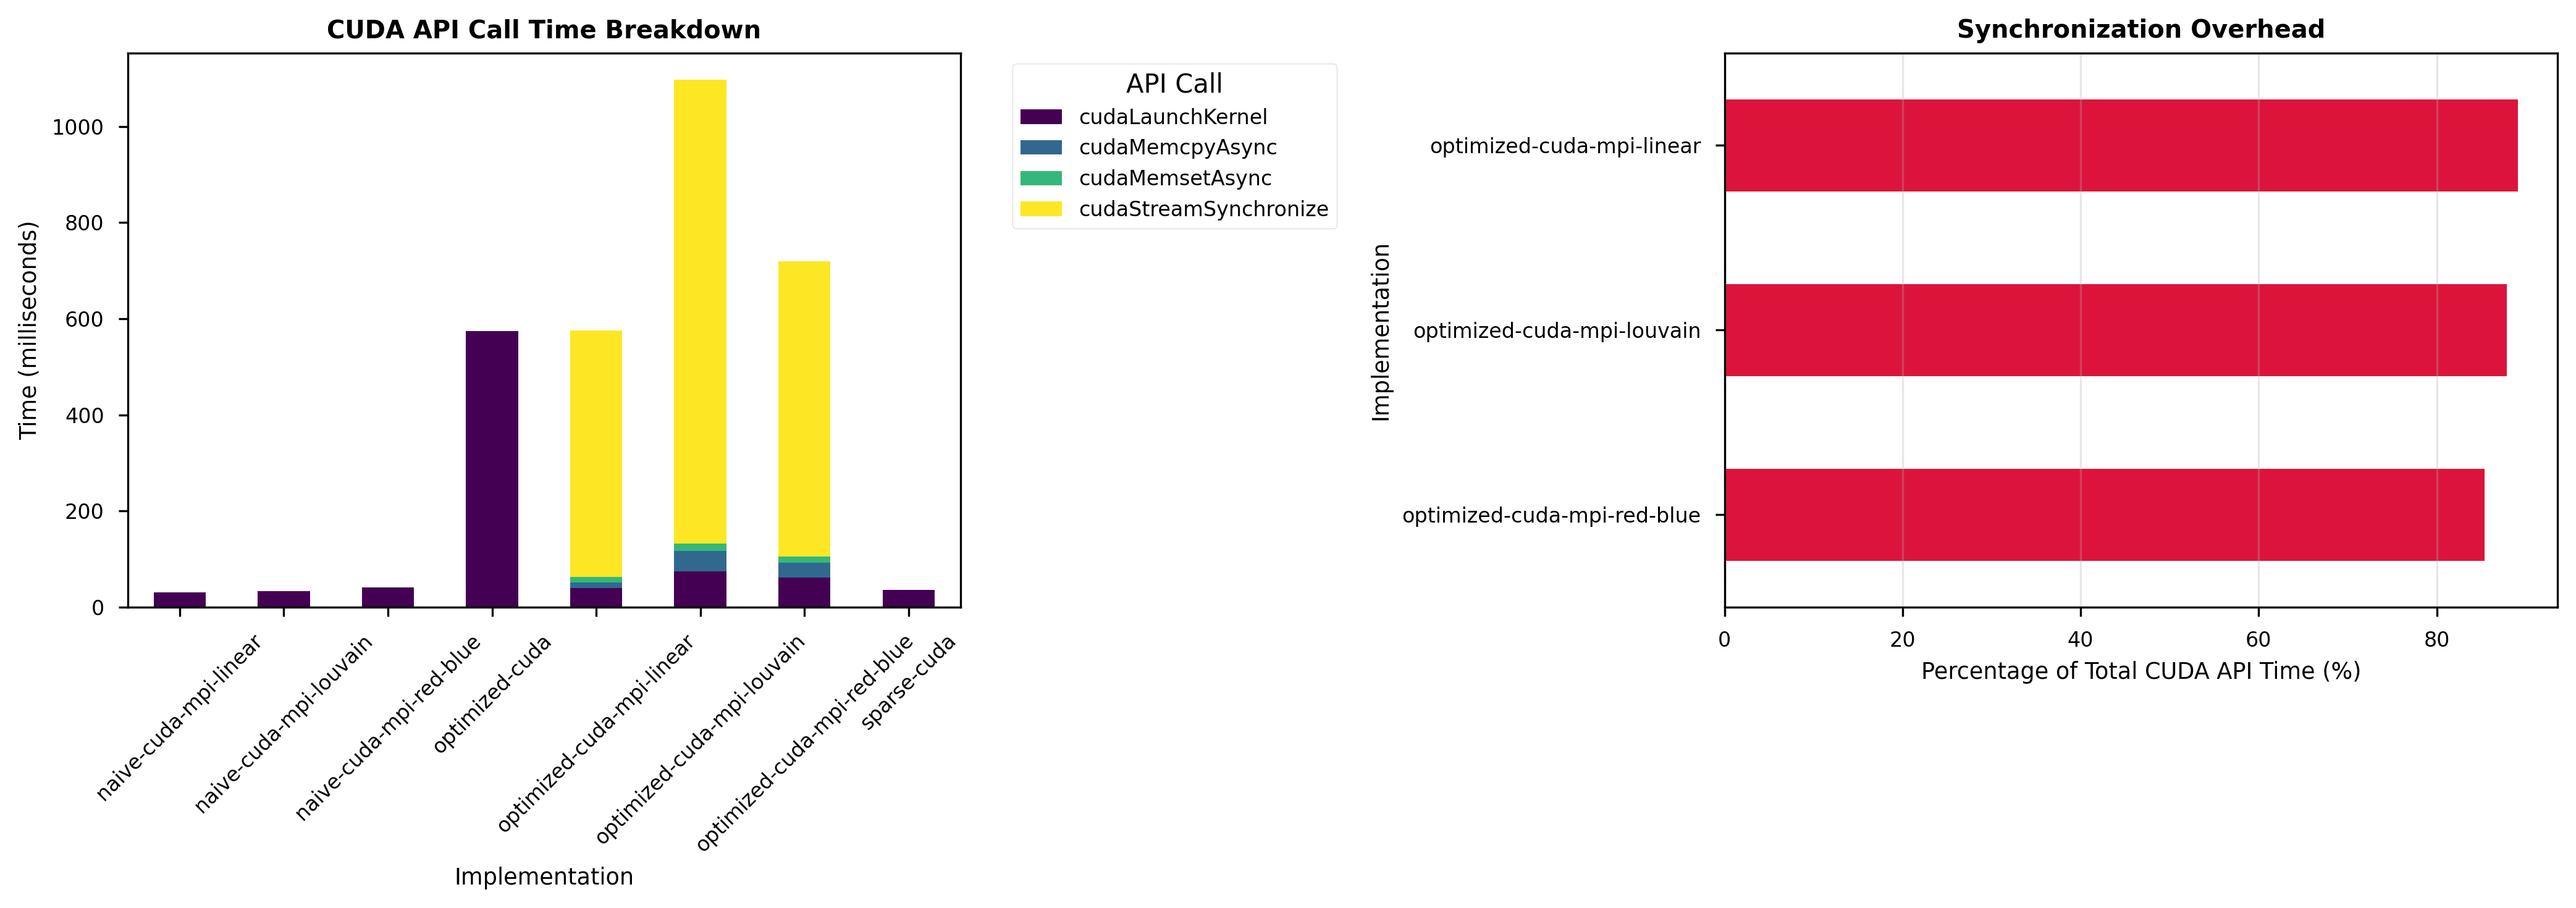


CUDA API Call Summary:

optimized-cuda:
             api_call    time_ms  num_calls
     cudaLaunchKernel 574.627428       4100
cudaDeviceSynchronize 254.084341          1
      cuProfilerStart   1.051181          1
           cudaMemcpy   0.037288          1

sparse-cuda:
             api_call     time_ms  num_calls
cudaDeviceSynchronize 3972.178230       2050
     cudaLaunchKernel   35.287221       6150
           cudaMemcpy    0.041116          1
      cuProfilerStart    0.004543          1

naive-cuda-mpi-linear:
             api_call    time_ms  num_calls
cudaDeviceSynchronize 496.928407       4100
           cudaMemcpy  71.057055       4101
     cudaLaunchKernel  30.619493       4100
      cuProfilerStart   0.003771          1

naive-cuda-mpi-louvain:
             api_call    time_ms  num_calls
           cudaMemcpy 526.175115       4101
cudaDeviceSynchronize 442.966472       4100
     cudaLaunchKernel  33.412442       4100
      cuProfilerStart   0.009082          1

naive-cuda

In [22]:
# Analyze CUDA API overhead
cuda_api_data = load_all_implementations("stats_cuda_api_sum.csv")

api_breakdown = []
for impl, df in cuda_api_data.items():
    if df is not None and not df.empty:
        for _, row in df.iterrows():
            api_breakdown.append({
                'implementation': impl,
                'api_call': row['Name'],
                'time_ms': row['Total Time (ns)'] / 1e6,
                'percentage': row['Time (%)'],
                'num_calls': row['Num Calls']
            })

api_df = pd.DataFrame(api_breakdown)

if not api_df.empty:
    # Focus on major API calls
    major_apis = ['cudaStreamSynchronize', 'cudaLaunchKernel', 'cudaMemcpyAsync', 'cudaMemsetAsync']
    api_df_filtered = api_df[api_df['api_call'].isin(major_apis)]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: API call time breakdown
    ax = axes[0]
    pivot_api = api_df_filtered.pivot_table(index='implementation', columns='api_call',
                                            values='time_ms', fill_value=0)
    pivot_api.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title('CUDA API Call Time Breakdown', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (milliseconds)')
    ax.legend(title='API Call', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    
    # Plot 2: Synchronization overhead percentage
    ax = axes[1]
    sync_data = api_df[api_df['api_call'] == 'cudaStreamSynchronize']
    if not sync_data.empty:
        sync_pct = sync_data.set_index('implementation')['percentage'].sort_values()
        sync_pct.plot(kind='barh', ax=ax, color='crimson')
        ax.set_title('Synchronization Overhead', fontweight='bold')
        ax.set_xlabel('Percentage of Total CUDA API Time (%)')
        ax.set_ylabel('Implementation')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cuda_api_overhead.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'cuda_api_overhead.png', bbox_inches='tight')
    plt.show()
    
    print("\nCUDA API Call Summary:")
    for impl in api_df['implementation'].unique():
        impl_data = api_df[api_df['implementation'] == impl]
        print(f"\n{impl}:")
        print(impl_data[['api_call', 'time_ms', 'num_calls']].to_string(index=False))
else:
    print("No CUDA API data available.")

## Summary Statistics Table

Generate a comprehensive table for inclusion in the paper.

In [23]:
# Create comprehensive summary table
summary_rows = []

for impl in ALL_IMPLS:
    # CUDA metrics
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv")
    if gpu_df is not None:
        cuda_kernel_time = gpu_df[gpu_df['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum() / 1e9
        cuda_total_time = gpu_df['Total Time (ns)'].sum() / 1e9
    else:
        cuda_kernel_time = cuda_total_time = 0
    
    # MPI metrics
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv")
    mpi_time = mpi_df['Total Time (ns)'].sum() / 1e9 if mpi_df is not None else 0
    
    # Message volume
    msg_df = load_csv_safely(impl, "stats_mpi_msg_size_sum.csv")
    msg_volume = msg_df['Total Message Volume'].sum() / (1024*1024) if msg_df is not None else 0
    
    total_time = cuda_total_time + mpi_time
    
    summary_rows.append({
        'Implementation': impl,
        'Total Time (s)': f"{total_time:.3f}",
        'CUDA Kernel (s)': f"{cuda_kernel_time:.3f}",
        'CUDA Total (s)': f"{cuda_total_time:.3f}",
        'MPI Time (s)': f"{mpi_time:.3f}",
        'MPI Volume (MB)': f"{msg_volume:.2f}",
        'Comm. Ratio (%)': f"{(mpi_time/total_time*100):.1f}" if total_time > 0 else "N/A"
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Save to CSV for LaTeX table generation
summary_df.to_csv(OUTPUT_DIR / 'performance_summary.csv', index=False)
print(f"\nSummary table saved to: {OUTPUT_DIR / 'performance_summary.csv'}")

Error loading results/nsys/20260104_162939/optimized-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/optimized-cuda/snp_profile_stats_mpi_msg_size_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/sparse-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
Error loading results/nsys/20260104_162939/sparse-cuda/snp_profile_stats_mpi_msg_size_sum.csv: No columns to parse from file

COMPREHENSIVE PERFORMANCE SUMMARY
             Implementation Total Time (s) CUDA Kernel (s) CUDA Total (s) MPI Time (s) MPI Volume (MB) Comm. Ratio (%)
             optimized-cuda          1.656           0.826          1.656        0.000            0.00             0.0
                sparse-cuda          7.917           3.910          7.917        0.000            0.00             0.0
      naive-cuda-mpi-linear          2.218           0.458          1.068        1.149           96.22      

## LaTeX Table Generation

Generate LaTeX code for direct inclusion in the paper.

In [24]:
# Generate LaTeX table
latex_table = summary_df.to_latex(index=False, 
                                   caption='Performance comparison of SNP system implementations',
                                   label='tab:performance',
                                   position='htbp',
                                   column_format='l' + 'r'*(len(summary_df.columns)-1))

# Save LaTeX table
with open(OUTPUT_DIR / 'performance_table.tex', 'w') as f:
    f.write(latex_table)

print("LaTeX Table for Paper:")
print("="*80)
print(latex_table)
print("="*80)
print(f"\nLaTeX table saved to: {OUTPUT_DIR / 'performance_table.tex'}")

LaTeX Table for Paper:
\begin{table}[htbp]
\caption{Performance comparison of SNP system implementations}
\label{tab:performance}
\begin{tabular}{lrrrrrr}
\toprule
Implementation & Total Time (s) & CUDA Kernel (s) & CUDA Total (s) & MPI Time (s) & MPI Volume (MB) & Comm. Ratio (%) \\
\midrule
optimized-cuda & 1.656 & 0.826 & 1.656 & 0.000 & 0.00 & 0.0 \\
sparse-cuda & 7.917 & 3.910 & 7.917 & 0.000 & 0.00 & 0.0 \\
naive-cuda-mpi-linear & 2.218 & 0.458 & 1.068 & 1.149 & 96.22 & 51.8 \\
naive-cuda-mpi-louvain & 2.614 & 0.853 & 1.868 & 0.746 & 129.23 & 28.5 \\
naive-cuda-mpi-red-blue & 2.752 & 0.844 & 1.908 & 0.844 & 96.22 & 30.7 \\
optimized-cuda-mpi-linear & 1.213 & 0.450 & 1.033 & 0.179 & 16.06 & 14.8 \\
optimized-cuda-mpi-louvain & 2.647 & 0.876 & 1.988 & 0.658 & 16.73 & 24.9 \\
optimized-cuda-mpi-red-blue & 1.653 & 0.557 & 1.289 & 0.364 & 32.08 & 22.0 \\
\bottomrule
\end{tabular}
\end{table}


LaTeX table saved to: results/nsys/20260104_162939/figures/performance_table.tex


## Analysis Complete

All visualizations have been generated and saved to the output directory. Files include:
- PDF and PNG versions of all plots (for paper submission)
- CSV summary data
- LaTeX table code

### Key Findings to Highlight in Paper:

1. **GPU Acceleration Effectiveness**: Quantify how much time is spent in CUDA kernels vs overhead
2. **MPI Communication Impact**: Show communication overhead ratio for distributed implementations
3. **Partitioning Strategy Benefits**: Compare linear vs graph-based partitioning effectiveness
4. **Optimization Impact**: Demonstrate naive vs optimized implementation improvements
5. **Scalability Bottlenecks**: Identify whether communication or computation limits performance